In [1]:
from pathlib import Path
from src.vlm_score import compute_vlm_score
from src.pixel_score import compute_all_metrics
import time

RUNS_DIR = Path("/Users/jonathansickert/git/3DFrontBench/runs")
DATASET_PATH = Path("/Users/jonathansickert/git/3DFrontBench/dataset")

In [5]:
import json as _json

results = {}

for run in RUNS_DIR.iterdir():

    target_path = DATASET_PATH / run.name / "color.png"
    results[run.name] = {}

    for render_path in run.glob("*.png"):

        # vlm_score = compute_vlm_score(target_path, render_path)
        pixel_score = compute_all_metrics(target_path, render_path)

        results[run.name][render_path.name] = pixel_score

Path("outputs").mkdir(exist_ok=True)
with open("outputs/results_kimi2.7.json", "w") as f:
    _json.dump(results, f, indent=2)
print(f"Saved outputs/results.json ({len(results)} runs)")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Users/jonathansickert/git/3DFrontBench/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /User

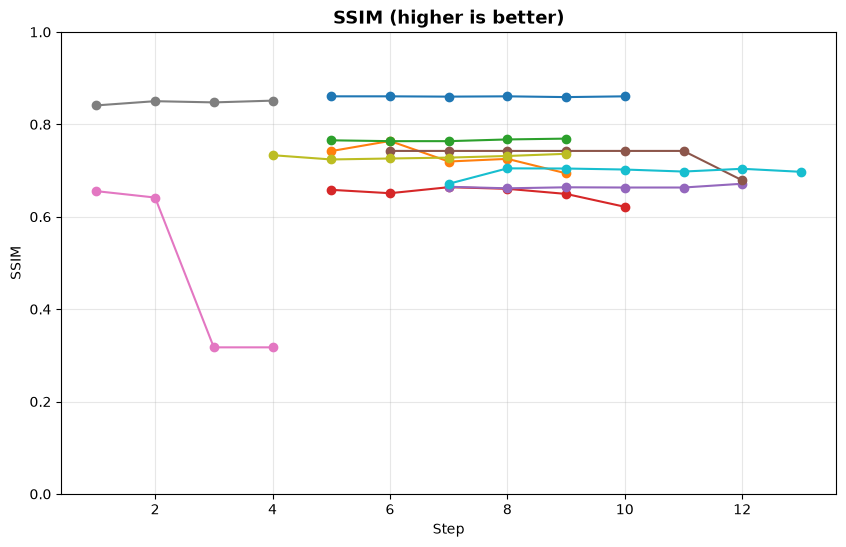

Saved outputs/metric_plots/ssim.png


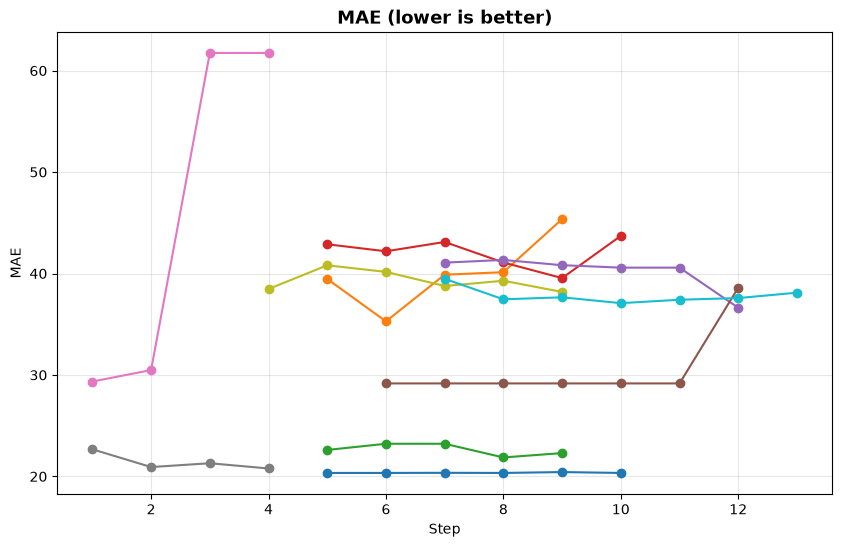

Saved outputs/metric_plots/mae.png


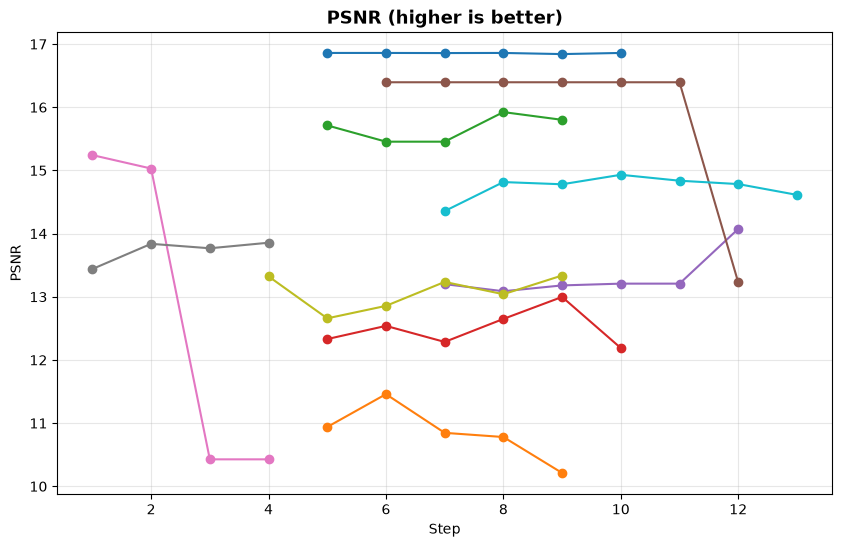

Saved outputs/metric_plots/psnr.png


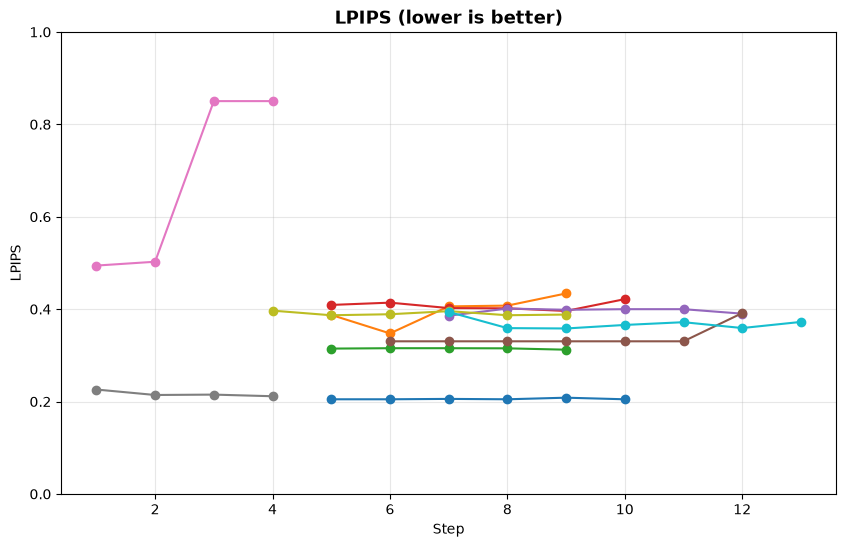

Saved outputs/metric_plots/lpips.png


In [16]:
import re
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

METRICS = ["ssim", "mae", "psnr", "lpips"]
METRIC_LABELS = {
    "ssim": "SSIM (higher is better)",
    "mae": "MAE (lower is better)",
    "psnr": "PSNR (higher is better)",
    "lpips": "LPIPS (lower is better)",
}
METRIC_YLIM = {
    "ssim": (0, 1),
    "mae" : None,
    "psnr": None,
    "lpips": (0, 1),
}

def step_from_filename(fname):
    m = re.search(r"color_(\d+)\.png", fname)
    return int(m.group(1)) if m else None

with open("outputs/results.json") as f:
    results_clean = json.load(f)

PLOTS_DIR = Path("outputs/metric_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

colors = cm.tab10(np.linspace(0, 1, len(results_clean)))

for metric in METRICS:
    fig, ax = plt.subplots(figsize=(10, 6))

    for (run_name, run_data), color in zip(sorted(results_clean.items()), colors):
        steps_metrics = []
        for fname, value in run_data.items():
            step = step_from_filename(fname)
            if step is None:
                continue
            pixel = value.get("pixel", value)
            steps_metrics.append((step, pixel[metric]))

        if not steps_metrics:
            continue
        steps_metrics.sort(key=lambda x: x[0])
        steps, vals = zip(*steps_metrics)

        short_name = re.sub(r"^[0-9a-f-]+_", "", run_name)
        ax.plot(steps, vals, marker="o", label=short_name, color=color)

    ax.set_title(METRIC_LABELS[metric], fontsize=13, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel(metric.upper())
    if METRIC_YLIM[metric] is not None:
        ax.set_ylim(*METRIC_YLIM[metric])
    # ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

    out_path = PLOTS_DIR / f"{metric}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")


In [7]:
import json as _json

vlm_results = {}

for run in RUNS_DIR.iterdir():

    target_path = DATASET_PATH / run.name / "color.png"
    vlm_results[run.name] = {}

    for render_path in run.glob("*.png"):

        vlm_score = compute_vlm_score(target_path, render_path)
        # pixel_score = compute_all_metrics(target_path, render_path)

        vlm_results[run.name][render_path.name] = vlm_score[0]
        time.sleep(10)

Path("outputs").mkdir(exist_ok=True)
with open("outputs/vlm_results_kimi.json", "w") as f:
    _json.dump(vlm_results, f, indent=2)
print(f"Saved outputs/vlm_results.json ({len(vlm_results)} runs)")


Saved outputs/vlm_results.json (18 runs)


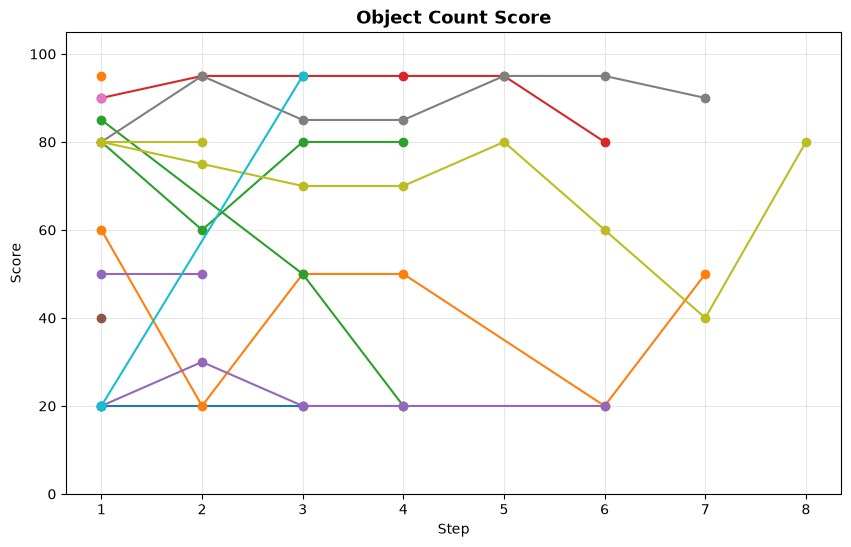

Saved outputs/metric_plots/object_count_kimi.png


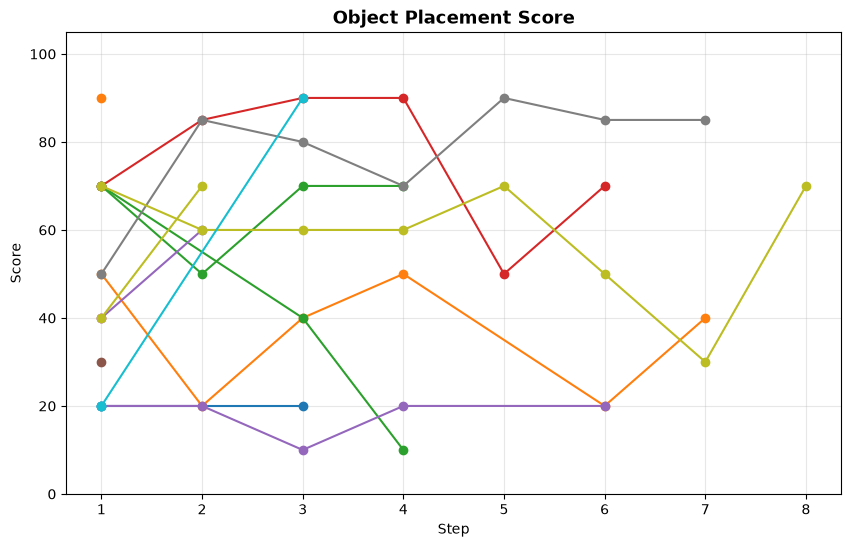

Saved outputs/metric_plots/object_placement_kimi.png


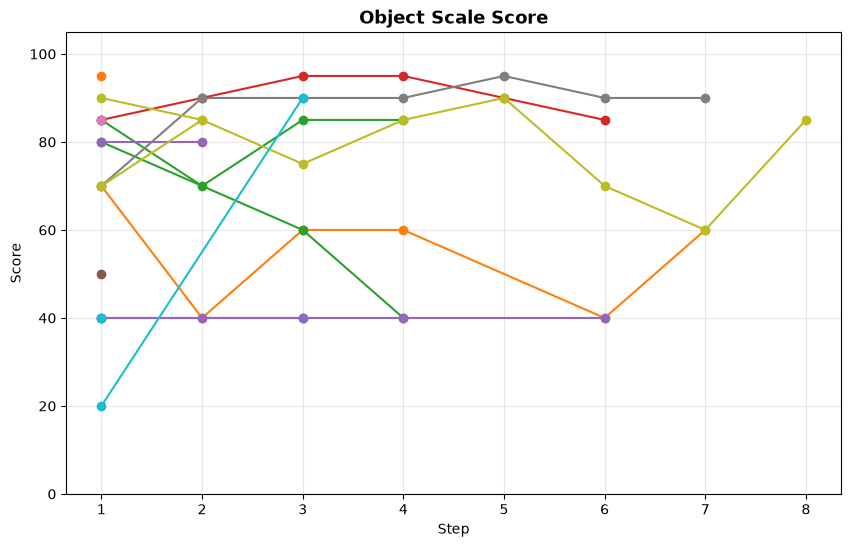

Saved outputs/metric_plots/object_scale_kimi.png


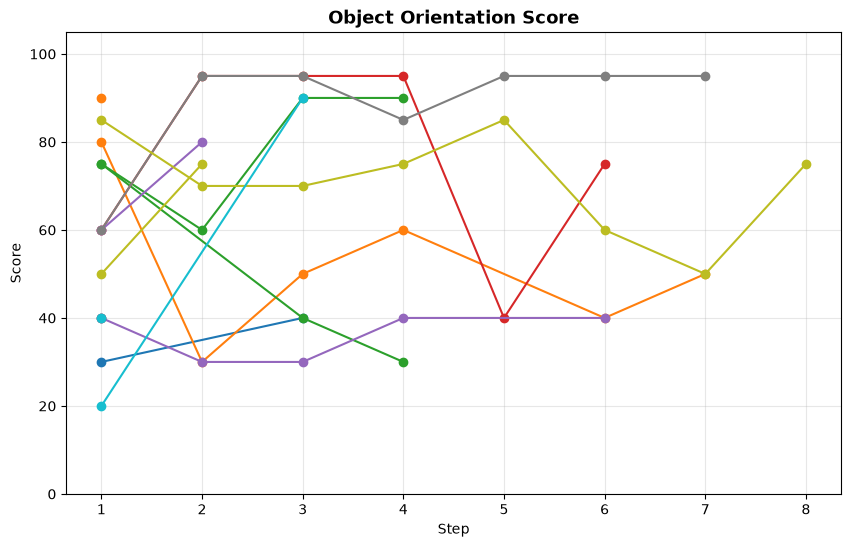

Saved outputs/metric_plots/object_orientation_kimi.png


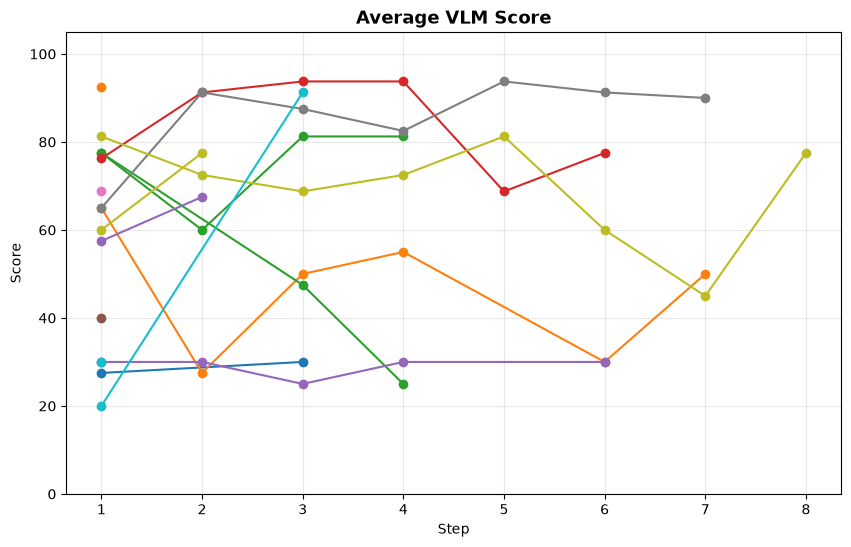

Saved outputs/metric_plots/average_kimi.png


In [20]:
import json
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

with open("outputs/vlm_results_kimi.json") as f:
    vlm_results = json.load(f)

VLM_METRICS = ["object_count", "object_placement", "object_scale", "object_orientation"]
VLM_METRIC_LABELS = {
    "object_count": "Object Count Score",
    "object_placement": "Object Placement Score",
    "object_scale": "Object Scale Score",
    "object_orientation": "Object Orientation Score",
}

def step_from_filename(fname):
    m = re.search(r"color_(\d+)\.png", fname)
    return int(m.group(1)) if m else None

VLM_PLOTS_DIR = Path("outputs/metric_plots")
VLM_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

colors = cm.tab10(np.linspace(0, 1, len(vlm_results)))

all_metrics = VLM_METRICS + ["average"]
all_labels = {**VLM_METRIC_LABELS, "average": "Average VLM Score"}

for metric in all_metrics:
    fig, ax = plt.subplots(figsize=(10, 6))

    for (run_name, run_data), color in zip(sorted(vlm_results.items()), colors):
        steps_metrics = []
        for fname, value in run_data.items():
            step = step_from_filename(fname)
            if step is None:
                continue
            scores = json.loads(value)
            if metric == "average":
                val = np.mean([scores[m] for m in VLM_METRICS])
            else:
                val = scores[metric]
            steps_metrics.append((step, val))

        if not steps_metrics:
            continue
        steps_metrics.sort(key=lambda x: x[0])
        steps, vals = zip(*steps_metrics)

        short_name = re.sub(r"^[0-9a-f-]+_", "", run_name)
        ax.plot(steps, vals, marker="o", label=short_name, color=color)

    ax.set_title(all_labels[metric], fontsize=13, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 105)
    # ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

    out_path = VLM_PLOTS_DIR / f"{metric}_kimi.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")


## Comparison

In [5]:
import json

with open("/Users/jonathansickert/git/3DFrontBench/outputs/results.json") as file:
    pixel_results_gemma = json.load(file)

with open("/Users/jonathansickert/git/3DFrontBench/outputs/vlm_results.json") as file:
    vlm_results_gemma = json.load(file)

with open("/Users/jonathansickert/git/3DFrontBench/outputs/results_kimi2.7.json") as file:
    pixel_results_kimi = json.load(file)

with open("/Users/jonathansickert/git/3DFrontBench/outputs/vlm_results_kimi.json") as file:
    vlm_results_kimi = json.load(file)


human_evaluation_gemma = {
    "LivingDiningRoom-10290" : (2, 2),
    "LivingDiningRoom-4293" : (6, 4),
    "Library-35224": (2, 2),
    "LivingDiningRoom-89516" : (3, 3),
    "Corridor-20684" : (7, 7),
    "LivingRoom-9915" : (8, 8),
    "LivingDiningRoom-44815" : (1, 1),
    "LivingDiningRoom-209062" : (3, 2),
    "LivingRoom-2922" : (2, 1),
}


human_evaluation_kimi = {
    "LivingDiningRoom-12554" : (4, 3),
    "LivingDiningRoom-10290" : (2, 2),
    "MasterBedroom-14403" : (3, 2),
    "LivingDiningRoom-180855" : (3, 3),
    "MasterBedroom-5966" : (2, 2),
    "LivingDiningRoom-48379" : (6, 5),
    "LivingDiningRoom-847" : (2, 1),
    "LivingDiningRoom-9326" : (3, 1),
    "LivingDiningRoom-8149" : (7, 5),
    "LivingDiningRoom-89516" : (2, 4),
    "LivingRoom-38165" : (3, 3),
    "Corridor-20684" : (6, 5),
}

avg_human_eval_gemma = {k: sum(v)/2 for k, v in human_evaluation_gemma.items()}
avg_human_eval_kimi = {k: sum(v)/2 for k, v in human_evaluation_kimi.items()}

In [6]:
avg_human_eval_gemma

{'LivingDiningRoom-10290': 2.0,
 'LivingDiningRoom-4293': 5.0,
 'Library-35224': 2.0,
 'LivingDiningRoom-89516': 3.0,
 'Corridor-20684': 7.0,
 'LivingRoom-9915': 8.0,
 'LivingDiningRoom-44815': 1.0,
 'LivingDiningRoom-209062': 2.5,
 'LivingRoom-2922': 1.5}